In [1]:
import pandas as pd
import matplotlib.pyplot as plt
customers = pd.read_excel('ecommerce_cleaned_data.xlsx', sheet_name='Customers')
products = pd.read_excel('ecommerce_cleaned_data.xlsx', sheet_name='Products')
orders = pd.read_excel('ecommerce_cleaned_data.xlsx', sheet_name='Orders')
returns = pd.read_excel('ecommerce_cleaned_data.xlsx', sheet_name='Returns')
activity = pd.read_excel('ecommerce_cleaned_data.xlsx', sheet_name='Customer_Activity')

activity.head()

,Customer_ID,Activity_Date,Login_Count,Session_Minutes,Orders_Count,Support_Tickets,App_Usage
0,CUST02237,2026-05-08,3,44.3,2,1,Yes
1,CUST00280,2026-05-30,6,26.4,3,1,No
2,CUST01552,2026-08-06,8,47.8,3,2,Yes
3,CUST02320,2026-04-08,6,11.6,2,2,Yes
4,CUST00803,2025-12-23,1,48.6,3,2,No


In [2]:
orders['order_total']= orders['Quantity']*orders['Unit_Price']*(1-orders['Discount'])

total_revenue= orders['order_total'].sum()
total_order= orders['Order_ID'].nunique()
total_units_sold = orders['Quantity'].sum()
avg_order_value = orders['order_total'].mean()

print(f"total_revenue: {total_revenue:,.2f}")
print(f"total_order: {total_order}")
print(f"total_uinits_sold: {total_units_sold:,.0f}")
print(f"Average Order Value (AOV): {avg_order_value:,.2f}")





total_revenue: 86,254,985.65
total_order: 9921
total_uinits_sold: 24,985
Average Order Value (AOV): 8,694.18


In [3]:
orders['Order_Month'] = orders['Order_Date'].dt.to_period('M')

monthly_sales= orders.groupby('Order_Month')['order_total'].sum().reset_index()
monthly_sales['order_total'] = monthly_sales['order_total'].round(2)
monthly_sales

,Order_Month,order_total
0,2024-09,1014545.63
1,2024-10,2146720.10
2,2024-11,2012896.87
3,2024-12,2236483.20
4,2025-01,2507958.66
5,2025-02,2191804.99
6,2025-03,2524915.13
7,2025-04,3009369.42
8,2025-05,2678171.52
9,2025-06,3288595.65


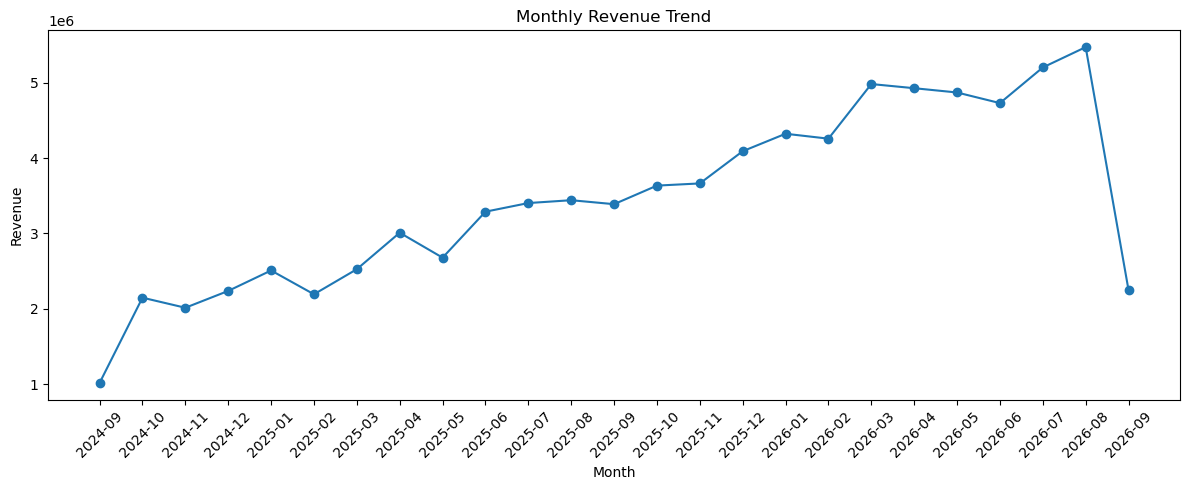

In [4]:
monthly_sales['Order_Month'] = monthly_sales['Order_Month'].astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales['Order_Month'], monthly_sales['order_total'],marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

In [5]:
# 1. Region-wise customer count
print("Customers by Region:")
print(customers['Region'].value_counts())
print()

# 2. Gender distribution
print("Customers by Gender:")
print(customers['Gender'].value_counts())
print()

# 3. Customer Segment breakdown
print("Customers by Segment:")
print(customers['Customer_Segment'].value_counts())
print()

# 4. Age statistics
print("Age Summary:")
print(customers['Age'].describe())

Customers by Region:
Region
North    1238
South     858
West      606
East      298
Name: count, dtype: int64

Customers by Gender:
Gender
Male       1462
Female     1448
Unknown      90
Name: count, dtype: int64

Customers by Segment:
Customer_Segment
Premium     1017
VIP          965
Standard     958
Unknown       60
Name: count, dtype: int64

Age Summary:
count    3000.000000
mean       38.997667
std        11.973113
min        18.000000
25%        29.000000
50%        39.000000
75%        49.000000
max        60.000000
Name: Age, dtype: float64


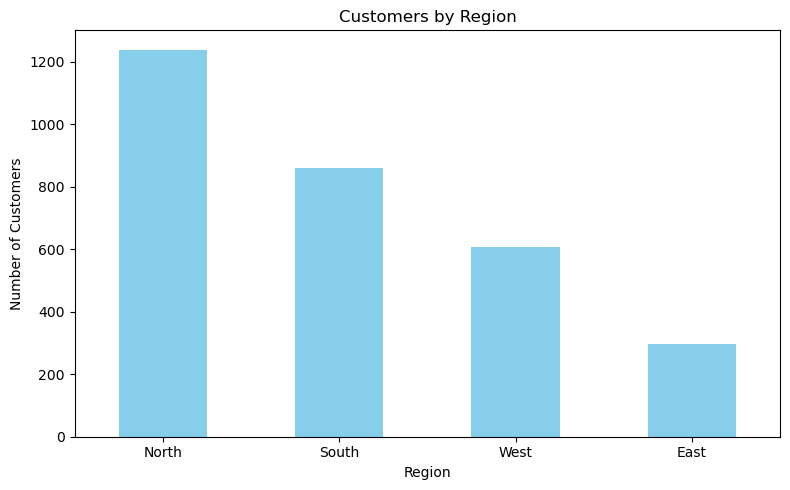

In [6]:
plt.figure(figsize=(8,5))
customers['Region'].value_counts().plot(kind='bar', color='skyblue')
plt.title('Customers by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [7]:
# Orders ko Products ke saath merge karo (Category/Product_Name lane ke liye)
orders_products = orders.merge(products[['Product_ID', 'Product_Name', 'Category', 'Sub_Category']], 
                                 on='Product_ID', how='left')

# 1. Top 10 Best-Selling Products (by Revenue)
top_products = orders_products.groupby('Product_Name')['order_total'].sum().sort_values(ascending=False).head(10)
print("Top 10 Products by Revenue:")
print(top_products)
print()

# 2. Bottom 10 Products (by Revenue)
bottom_products = orders_products.groupby('Product_Name')['order_total'].sum().sort_values(ascending=True).head(10)
print("Bottom 10 Products by Revenue:")
print(bottom_products)
print()

# 3. Category-wise performance
category_sales = orders_products.groupby('Category')['order_total'].sum().sort_values(ascending=False)
print("Category-wise Revenue:")
print(category_sales)
print()

# 4. Category-wise order count
category_orders = orders_products.groupby('Category')['Order_ID'].nunique().sort_values(ascending=False)
print("Category-wise Order Count:")
print(category_orders)

Top 10 Products by Revenue:
Product_Name
Skincare Item 96               942773.6110
Mobile Accessories Item 192    807903.4175
Yoga Item 274                  755262.0920
Makeup Item 73                 749087.1690
Women Item 190                 678810.4095
Skincare Item 289              673101.6000
Kitchen Item 282               670303.4145
Haircare Item 121              667468.8930
Wearables Item 105             665796.4950
Skincare Item 268              649032.5380
Name: order_total, dtype: float64

Bottom 10 Products by Revenue:
Product_Name
Yoga Item 177         9559.6045
Cameras Item 95      10653.8250
Footwear Item 152    15173.0400
Men Item 284         15976.3200
Cameras Item 68      20597.1760
Bedding Item 300     20918.3200
Women Item 267       22194.9680
Haircare Item 281    22706.8515
Outdoor Item 50      25405.9260
Outdoor Item 210     28356.9975
Name: order_total, dtype: float64

Category-wise Revenue:
Category
Electronics    2.119223e+07
Beauty         1.811898e+07
Fashion

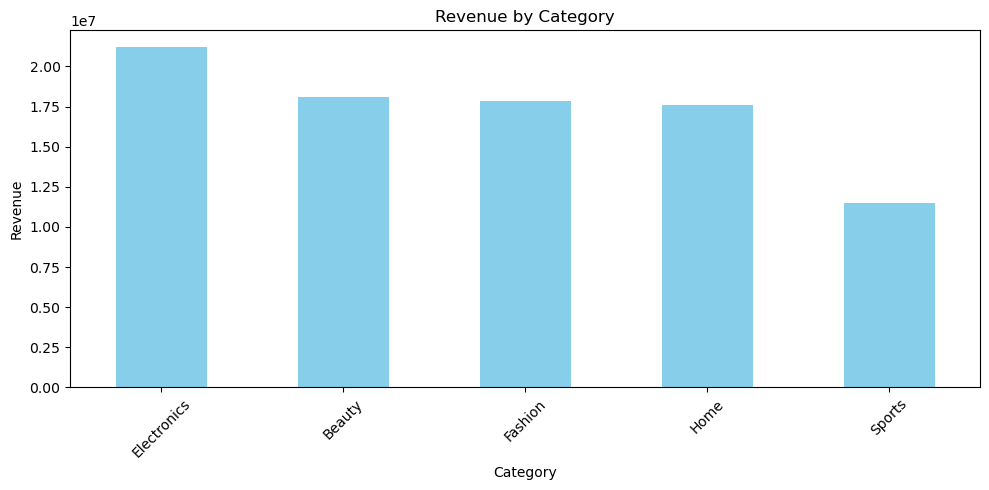

In [8]:
plt.figure(figsize=(10,5))
category_sales.plot(kind='bar', color='skyblue')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
# 1. Monthly Order Count Trend (sirf revenue nahi, orders ki ginti bhi)
monthly_orders = orders.groupby('Order_Month')['Order_ID'].nunique()
print("Monthly Order Count:")
print(monthly_orders)
print()

# 2. Day-of-Week Pattern — kaunse din zyada orders aate hain
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
orders['Day_of_Week'] = orders['Order_Date'].dt.day_name()
day_pattern = orders.groupby('Day_of_Week')['Order_ID'].nunique().reindex(day_order)
print("Orders by Day of Week:")
print(day_pattern)
print()

# 3. Payment Method Trend
payment_trend = orders['Payment_Method'].value_counts()
print("Payment Method Distribution:")
print(payment_trend)

Monthly Order Count:
Order_Month
2024-09    124
2024-10    239
2024-11    248
2024-12    274
2025-01    282
2025-02    255
2025-03    269
2025-04    326
2025-05    345
2025-06    366
2025-07    366
2025-08    393
2025-09    388
2025-10    453
2025-11    461
2025-12    490
2026-01    500
2026-02    477
2026-03    548
2026-04    555
2026-05    572
2026-06    536
2026-07    593
2026-08    629
2026-09    232
Freq: M, Name: Order_ID, dtype: int64

Orders by Day of Week:
Day_of_Week
Monday       1459
Tuesday      1434
Wednesday    1396
Thursday     1422
Friday       1409
Saturday     1348
Sunday       1453
Name: Order_ID, dtype: int64

Payment Method Distribution:
Payment_Method
Net Banking    1976
Credit Card    1923
COD            1916
Debit Card     1910
UPI            1907
Unknown         289
Name: count, dtype: int64


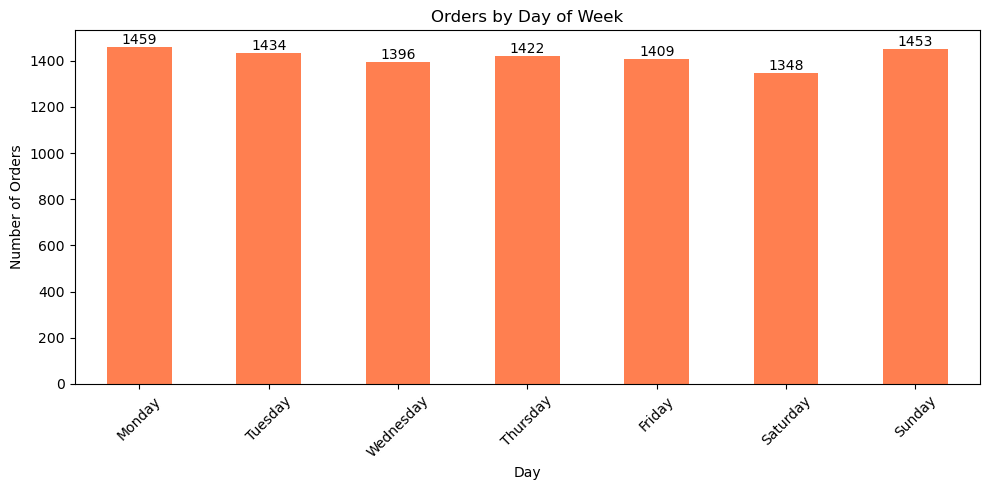

In [10]:
plt.figure(figsize=(10,5))
ax = day_pattern.plot(kind='bar', color='coral')

# Har bar ke upar value likho
for i, value in enumerate(day_pattern):
    ax.text(i, value, str(value), ha='center', va='bottom')

plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Chart 1: Category-wise Revenue 

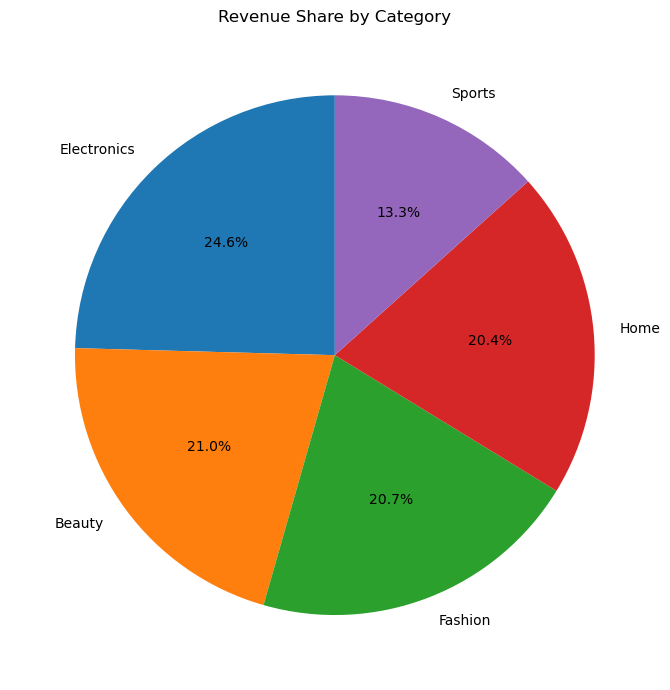

In [11]:
plt.figure(figsize=(7,7))
category_sales.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title('Revenue Share by Category')
plt.ylabel('')
plt.tight_layout()
plt.show()

## Chart 2: Top 10 Products

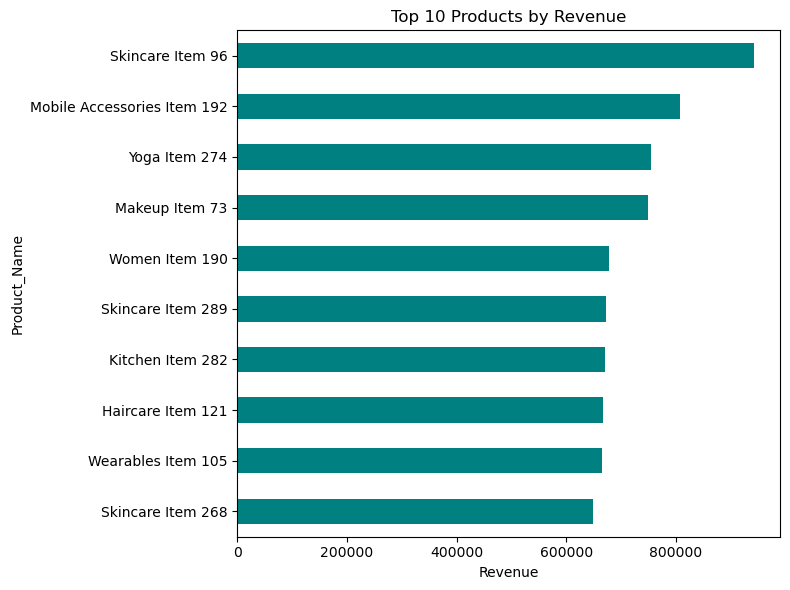

In [12]:
plt.figure(figsize=(8,6))
top_products.sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Products by Revenue')
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

## Chart 3: Customer Distribution by Region 

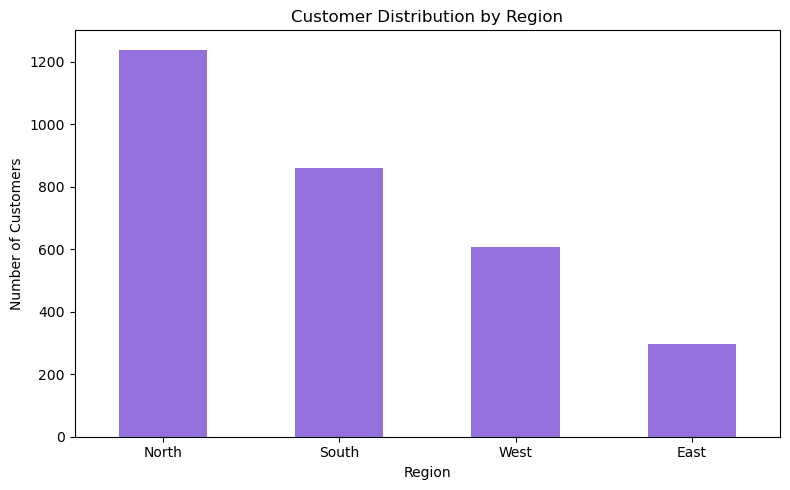

In [13]:
plt.figure(figsize=(8,5))
customers['Region'].value_counts().plot(kind='bar', color='mediumpurple')
plt.title('Customer Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Chart 4: Age Distribution

<Axes: ylabel='Frequency'>

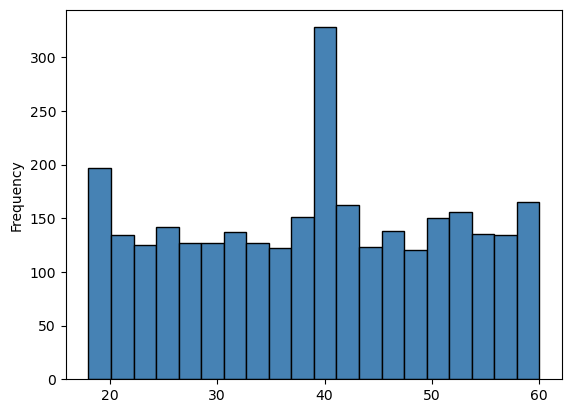

In [14]:
customers['Age'].plot(kind='hist',bins= 20,color='steelblue',edgecolor='black')

## Chart 5: Payment Method Distribution

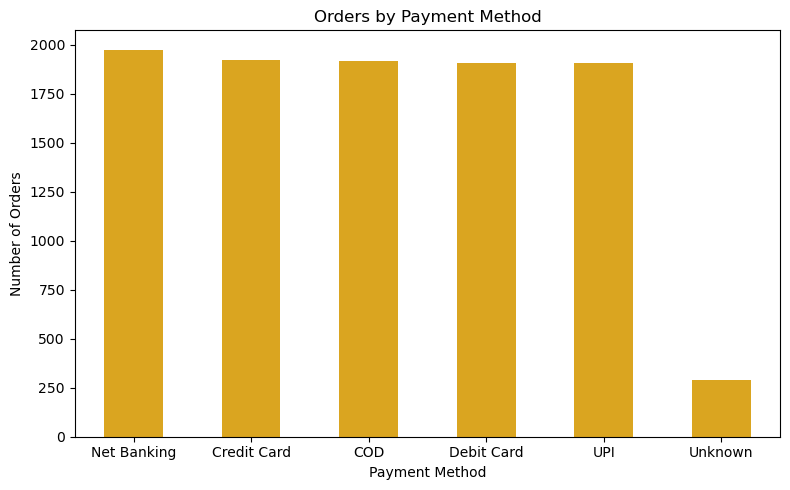

In [15]:
plt.figure(figsize=(8,5))
orders['Payment_Method'].value_counts().plot(kind='bar', color='goldenrod')
plt.title('Orders by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Number of Orders')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()